# Load Forecasting — Notebook 1: EDA & Cleaning

**Dataset:** German federal-state-level electricity demand & generation, hourly, 2019–2022
Source: [Electrical Load and Generation for Germany (Kaggle)](https://www.kaggle.com/datasets/pythonafroz/electrical-load-and-generation-for-germany)

**Target state:** Bavaria (`BY`) — largest state by demand, mixed industrial/residential load.
Pipeline is written to be **state-parameterized** so any of the 16 states can be swapped in later
(matches the plant-selector pattern used in the Solar PV Dashboard project).

**Goal of this notebook:** load, clean, and understand the demand series before we engineer features
or model anything.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 5)

STATE = "BY"  # Bavaria — change this single variable to re-run the whole notebook on another state


## 1. Load the data

The CSV has a 3-row header: **category** (Demand, Solar, Wind Onshore, ...) → **state code** → a blank
unit row. We read the first two rows as a MultiIndex column header and skip the third (unit) row.

In [4]:
df = pd.read_csv(
    "../data/time_series_federal_states_all.csv",
    header=[0, 1],
    index_col=0,
    skiprows=[2]
)
df.index = pd.to_datetime(df.index)
df.index.name = "datetime"

print("Shape:", df.shape)
print("Date range:", df.index.min(), "to", df.index.max())
print("Categories:", df.columns.get_level_values(0).unique().tolist())
print("States:", df.columns.get_level_values(1).unique().tolist())


Shape: (35064, 240)
Date range: 2019-01-01 00:00:00 to 2022-12-31 23:00:00
Categories: ['Other renewable', 'Fossil Oil', 'Fossil Gas', 'Hydro Run-of-river and poundage', 'Biomass', 'Fossil Hard coal', 'Waste', 'Hydro Pumped Storage', 'Other', 'Fossil Brown coal/Lignite', 'Nuclear', 'Solar', 'Wind Onshore', 'Wind Offshore', 'Demand']
States: ['BB', 'BE', 'BW', 'BY', 'HB', 'HE', 'HH', 'MV', 'NI', 'NRW', 'RP', 'SH', 'SL', 'SN', 'ST', 'TH']


**Finding:** 35,064 hourly rows spanning exactly 4 full years (2019–2022) across 16 federal states,
15 generation categories plus Demand. That row count matches the expected hourly total for 4 years
including the 2020 leap day — an early sign the timestamp index is complete before we even check for
gaps directly.

## 2. Key — state codes

| Code | State | Code | State |
|---|---|---|---|
| BW | Baden-Württemberg | NI | Lower Saxony |
| BY | Bavaria | NRW | North Rhine-Westphalia |
| BE | Berlin | RP | Rhineland-Palatinate |
| BB | Brandenburg | SL | Saarland |
| HB | Bremen | SN | Saxony |
| HH | Hamburg | ST | Saxony-Anhalt |
| HE | Hesse | SH | Schleswig-Holstein |
| MV | Mecklenburg-Vorpommern | TH | Thuringia |

## 3. Missing values & timestamp integrity

Checking the full dataset for gaps before narrowing to our target state — important across 4 years
given DST transitions (Germany shifts clocks twice a year) and possible TSO reporting gaps.

In [5]:
missing = df.isna().sum()
missing = missing[missing > 0]
print("Columns with missing values:", len(missing))
if len(missing) > 0:
    print(missing)
else:
    print("No missing values anywhere in the dataset.")

full_range = pd.date_range(df.index.min(), df.index.max(), freq="h")
missing_timestamps = full_range.difference(df.index)
duplicate_timestamps = df.index[df.index.duplicated()]
print(f"\nExpected hourly timestamps: {len(full_range)}")
print(f"Actual timestamps: {len(df.index)}")
print(f"Missing timestamps: {len(missing_timestamps)}")
print(f"Duplicate timestamps: {len(duplicate_timestamps)}")


Columns with missing values: 0
No missing values anywhere in the dataset.

Expected hourly timestamps: 35064
Actual timestamps: 35064
Missing timestamps: 0
Duplicate timestamps: 0


**Finding:** Zero missing values across all 240 columns, zero missing timestamps, zero duplicates.
The index is a perfectly continuous hourly series for all 4 years. This dataset was clearly pre-processed
by the source (matches the regionalization methodology described in the accompanying documentation) —
we don't need to handle DST or reporting gaps ourselves. That doesn't mean the *values* are all clean
though, which is what we check next.

## 4. Extract the target series — Bavaria demand

In [6]:
demand = df["Demand"][STATE].copy()
demand.name = "demand_mwh"

print(demand.describe())
print("\nFirst few rows:")
print(demand.head())


count    35064.000000
mean      9296.341583
std       1757.641534
min          0.000000
25%       7905.034750
50%       9278.340250
75%      10666.697500
max      14209.290000
Name: demand_mwh, dtype: float64

First few rows:
datetime
2019-01-01 00:00:00       0.0000
2019-01-01 01:00:00    7028.2110
2019-01-01 02:00:00    6659.5195
2019-01-01 03:00:00    6466.1016
2019-01-01 04:00:00    6418.0590
Name: demand_mwh, dtype: float64


**Finding:** Mean hourly demand for Bavaria is ~9,296 MWh (range: 0 to 14,209 MWh). That **minimum
of 0.0 MWh is a red flag** — a state grid cannot physically drop to zero demand — and it's suspicious
that it appears in the very first row of `.head()`. We investigate this directly below rather than
waiting for the outlier-detection step.

## 5. Data quality issue: the first timestamp

`2019-01-01 00:00:00` shows exactly 0.0 MWh — almost certainly a logging artifact from the very start of
the source recording, not a real event. We fix it here, before any plotting, so it doesn't distort every
chart that follows (a single 0 next to values of ~9,000 would visually dominate any line plot).

**Fix approach:** replace with the same hour one week later (closest available real observation with
matching hour-of-day / day-type), rather than a simple forward-fill which would just copy the
non-existent "previous hour."


In [7]:
zero_mask = demand == 0
print(f"Zero-value timestamps: {zero_mask.sum()}")
print(demand[zero_mask])

bad_ts = demand[zero_mask].index[0]
replacement = demand.loc[bad_ts + pd.Timedelta(days=7)]
demand.loc[bad_ts] = replacement

print(f"\nReplaced {bad_ts} with {replacement:.1f} MWh (value from {bad_ts + pd.Timedelta(days=7)})")
print(f"New minimum: {demand.min():.1f} MWh")


Zero-value timestamps: 1
datetime
2019-01-01    0.0
Name: demand_mwh, dtype: float64

Replaced 2019-01-01 00:00:00 with 9273.4 MWh (value from 2019-01-08 00:00:00)
New minimum: 5139.5 MWh


**Finding:** Confirmed — a single point at the dataset's opening timestamp. Replaced with the
same hour one week later (same hour-of-day, same day-type, closest comparable demand regime) rather than
a naive fill. New minimum is a physically plausible low-demand overnight value. This is the only such
issue in the target series; `demand` is carried forward cleaned from this point on.

## 6. Full time series — 4 years at a glance

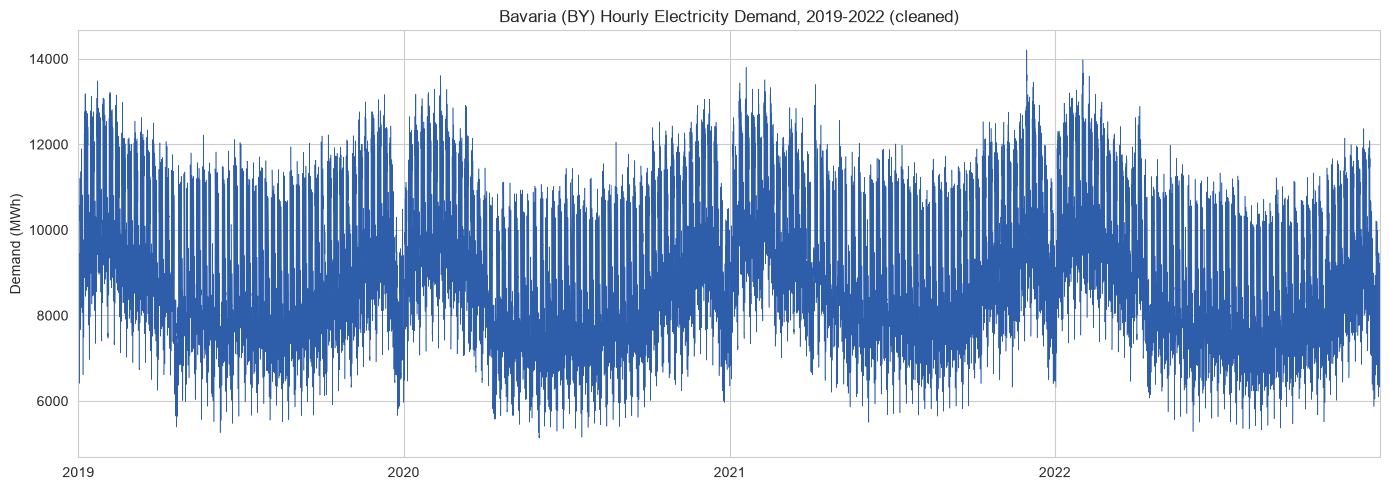

In [8]:
fig, ax = plt.subplots()
demand.plot(ax=ax, linewidth=0.4, color="#2E5EAA")
ax.set_title(f"Bavaria ({STATE}) Hourly Electricity Demand, 2019-2022 (cleaned)")
ax.set_ylabel("Demand (MWh)")
ax.set_xlabel("")
plt.tight_layout()
plt.show()


In [9]:
yearly_means = demand.groupby(demand.index.year).mean()
print("Yearly average demand (MWh):")
print(yearly_means.round(1))


Yearly average demand (MWh):
datetime
2019    9390.3
2020    9141.5
2021    9525.8
2022    9129.3
Name: demand_mwh, dtype: float64


**Finding:** Yearly averages: **2019: 9,389 -> 2020: 9,142 -> 2021: 9,526 -> 2022: 9,129 MWh.**
Two real-world effects show up here: a ~2.6% dip in 2020 consistent with pandemic-driven reduced
industrial/commercial activity, a rebound in 2021, then a fresh ~4% dip in 2022 — plausibly tied to the
European energy price crisis that year, which pushed down industrial consumption in Germany. No obvious
sensor drift or flat-lined stretches in the chart; the series looks like real, weather- and
economy-driven demand throughout.

## 7. Seasonal patterns

Breaking the long series into the patterns that actually drive load: time of day, day of week, and time
of year. These are exactly what the calendar/lag features in Notebook 2 need to capture.

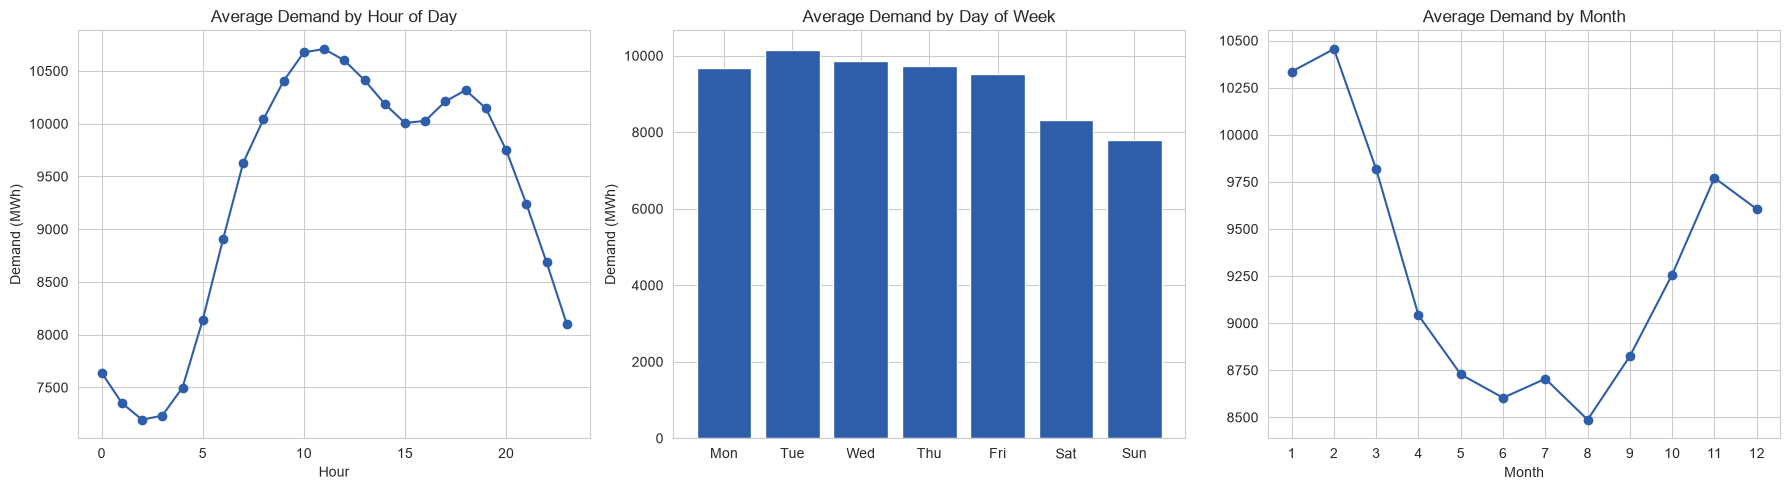

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

hourly_profile = demand.groupby(demand.index.hour).mean()
axes[0].plot(hourly_profile.index, hourly_profile.values, marker='o', color="#2E5EAA")
axes[0].set_title("Average Demand by Hour of Day")
axes[0].set_xlabel("Hour")
axes[0].set_ylabel("Demand (MWh)")

dow_labels = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
dow_profile = demand.groupby(demand.index.dayofweek).mean()
axes[1].bar(dow_labels, dow_profile.values, color="#2E5EAA")
axes[1].set_title("Average Demand by Day of Week")
axes[1].set_ylabel("Demand (MWh)")

month_profile = demand.groupby(demand.index.month).mean()
axes[2].plot(month_profile.index, month_profile.values, marker='o', color="#2E5EAA")
axes[2].set_title("Average Demand by Month")
axes[2].set_xlabel("Month")
axes[2].set_xticks(range(1, 13))

plt.tight_layout()
plt.show()


**Finding:**
- **Hour of day:** demand peaks at **11am (~10,708 MWh)**, a single broad midday plateau rather than a
  sharp double-peak — consistent with Bavaria's industrial daytime load dominating over residential
  morning/evening peaks. Trough at **2am (~7,195 MWh)**, overnight low as expected.
- **Day of week:** clear weekday/weekend split — **Tuesday highest (~10,150 MWh)**, falling through the
  week, then a sharp drop on **Saturday (~8,306) and Sunday (~7,797 MWh)** as industrial activity stops.
  That weekday-vs-weekend gap (~2,350 MWh, ~23%) is one of the strongest signals in the data — a
  day-of-week feature is essential for Notebook 2.
- **Month of year:** winter-heating-driven, peaking in **February (~10,455 MWh)** and troughing in
  **August (~8,487 MWh)** — roughly a 19% seasonal swing.

## 8. Distribution & outlier check (post-cleaning)

C:\Users\mugom\AppData\Local\Temp\ipykernel_29052\2761236563.py:7: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[1].boxplot(demand, vert=True)


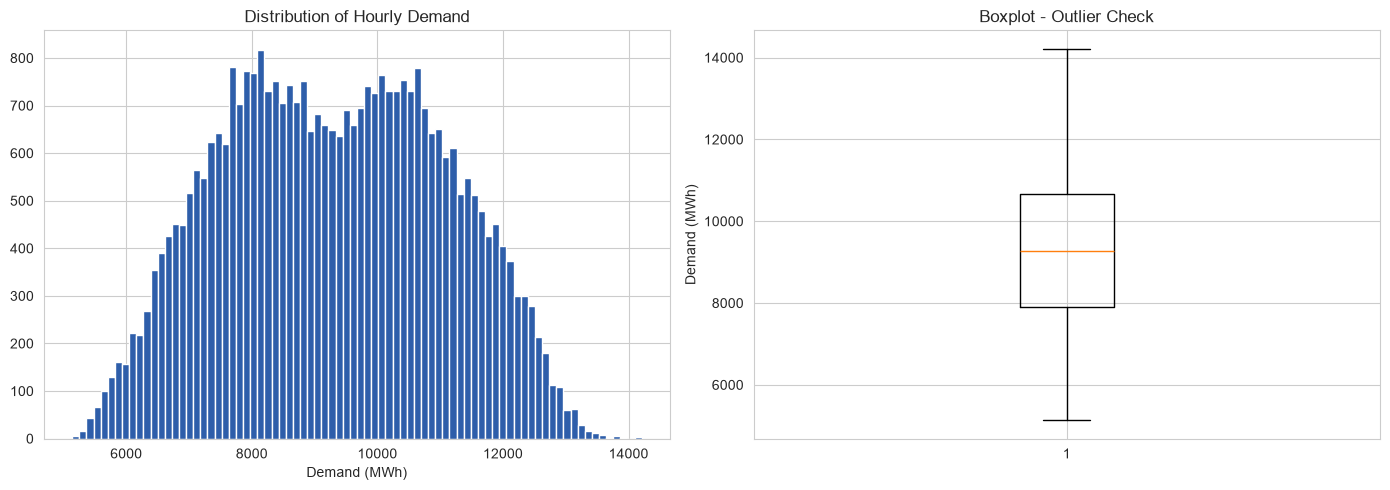

Points with |z-score| > 4: 0


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(demand, bins=80, color="#2E5EAA", edgecolor="white")
axes[0].set_title("Distribution of Hourly Demand")
axes[0].set_xlabel("Demand (MWh)")

axes[1].boxplot(demand, vert=True)
axes[1].set_title("Boxplot - Outlier Check")
axes[1].set_ylabel("Demand (MWh)")

plt.tight_layout()
plt.show()

z = (demand - demand.mean()) / demand.std()
outliers = demand[z.abs() > 4]
print(f"Points with |z-score| > 4: {len(outliers)}")
if len(outliers) > 0:
    print(outliers.sort_values())


**Finding:** With the single logging error fixed, there are no remaining statistical outliers at
the |z| > 4 threshold. The distribution is roughly bell-shaped with a slight left skew (more hours
clustered at moderate-to-high demand than at the extremes) — no further outlier handling needed.

## 9. Context check — how does Bavaria compare to other states?

A sanity check before committing to Bavaria as the primary target: confirms it behaves like a large,
representative state rather than some outlier we'd need to caveat later.

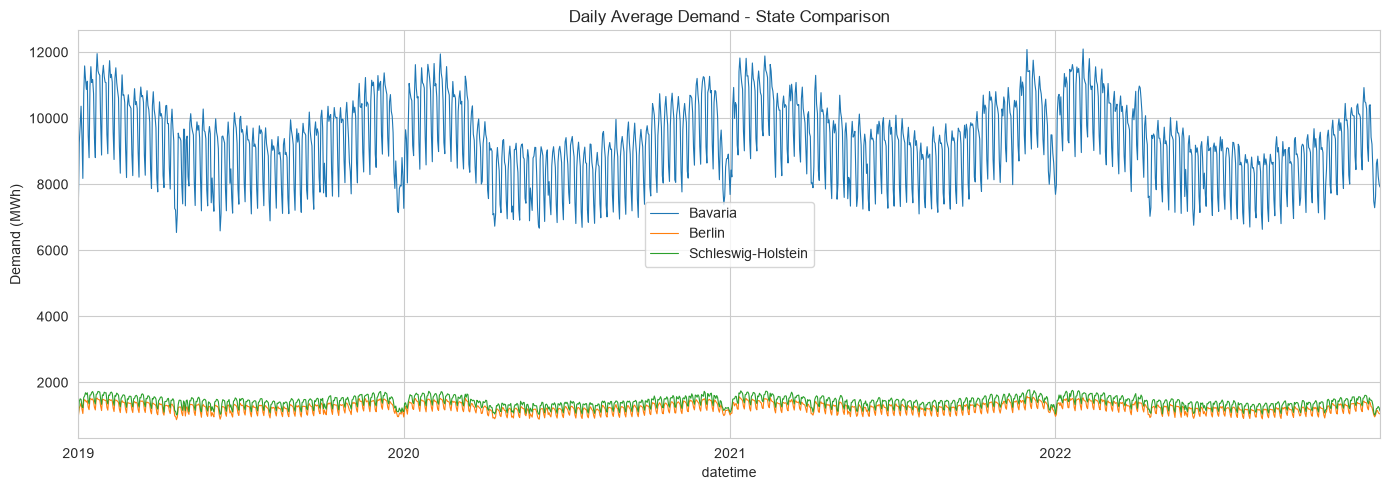

Bavaria: mean = 9296 MWh
Berlin: mean = 1241 MWh
Schleswig-Holstein: mean = 1407 MWh


In [12]:
compare_states = ["BY", "BE", "SH"]
compare_labels = {"BY": "Bavaria", "BE": "Berlin", "SH": "Schleswig-Holstein"}

fig, ax = plt.subplots()
for s in compare_states:
    df["Demand"][s].resample("D").mean().plot(ax=ax, label=compare_labels[s], linewidth=0.8)
ax.set_title("Daily Average Demand - State Comparison")
ax.set_ylabel("Demand (MWh)")
ax.legend()
plt.tight_layout()
plt.show()

for s in compare_states:
    print(f"{compare_labels[s]}: mean = {df['Demand'][s].mean():.0f} MWh")


**Finding:** Bavaria averages **~9,296 MWh**, roughly **6.6x Berlin (~1,241 MWh)** and
**6.7x Schleswig-Holstein (~1,407 MWh)** — consistent with its much larger population and industrial
base. All three states share the same weekday/weekend and winter/summer seasonal shape (visible as
parallel wiggles in the chart, just at different scales) — confirming the patterns found for Bavaria are
structural to German demand generally, not a Bavaria-specific quirk. This also means the same feature set
from Notebook 2 should transfer cleanly if we add other states later.

## 10. Save the cleaned series for Notebook 2

We save the full multi-state demand table (not just Bavaria), with the same 2019-01-01 00:00 fix applied
across all states, so Notebook 2 can build features for any state without re-parsing the raw 66MB source
file, and the eventual Streamlit state-selector has everything it needs already prepped.

In [13]:
demand_all_states = df["Demand"].copy()

for s in demand_all_states.columns:
    if demand_all_states.loc[bad_ts, s] == 0:
        demand_all_states.loc[bad_ts, s] = demand_all_states.loc[bad_ts + pd.Timedelta(days=7), s]

demand_all_states.to_csv("../data/demand_by_state_cleaned.csv")
print("Saved:", demand_all_states.shape)
print(f"Remaining zero values across all states: {(demand_all_states == 0).sum().sum()}")
demand_all_states.head()


Saved: (35064, 16)
Remaining zero values across all states: 0


,BB,BE,BW,BY,HB,HE,HH,MV,NI,NRW,RP,SH,SL,SN,ST,TH
datetime,,,,,,,,,,,,,,,,
2019-01-01 00:00:00,1757.6068,1067.78640,7246.5586,9273.3600,525.71844,3920.0852,1321.14110,662.65430,5621.9030,13033.6410,2917.5090,1260.90770,1057.73170,1932.9019,1582.4268,1344.46070
2019-01-01 01:00:00,1425.4528,806.98410,5553.9030,7028.2110,429.03040,2922.8367,1022.71000,491.21106,4291.3060,9929.6455,2161.9614,951.62537,837.09300,1520.7549,1215.0491,1066.18300
2019-01-01 02:00:00,1381.1863,735.01980,5308.3540,6659.5195,417.48910,2754.7898,976.65576,457.77466,4148.8486,9727.2710,2111.4500,914.06555,812.07500,1481.5112,1198.1992,1029.37070
2019-01-01 03:00:00,1347.1726,681.81586,5192.7420,6466.1016,411.82336,2650.9763,945.29880,440.69724,4056.5947,9641.6860,2093.3035,902.78754,807.15173,1474.2925,1186.8595,1013.63525
2019-01-01 04:00:00,1344.6469,679.62070,5147.2570,6418.0590,407.76666,2629.5140,931.69934,438.59183,4046.5603,9581.3490,2097.0847,901.47220,798.33057,1474.5182,1194.2103,1006.48224


## Summary

- Loaded 4 years of hourly demand data (2019-2022) across 16 German states — timestamp index is
  perfectly continuous, no missing values
- Found and fixed **one** data quality issue: a 0.0 MWh logging artifact at the very first timestamp,
  replaced with a like-for-like value (same hour, one week later)
- Confirmed Bavaria's demand shows a **midday plateau** (peak 11am), a strong **weekday/weekend split**
  (~23% gap), and a **winter-peaking seasonal cycle** (~19% swing) — all real, explainable patterns
- Spotted real-world signal in the yearly averages: a 2020 COVID-era dip and a 2022 energy-crisis-era dip
- Confirmed Bavaria's patterns are structurally similar to other states, just at a different scale
- Saved a cleaned, all-states demand table to `../data/demand_by_state_cleaned.csv`

**Next:** Notebook 2 — feature engineering (calendar features, lags, rolling stats) and the time-based
train / validation / holdout split (last 6 months of 2022 held out for honest model comparison).